# AutoDiag AI : Complete Project Pipeline
**Capstone Project 2 · Intelligent Car Fault Diagnosis & Advisory Chatbot**

This notebook covers the full project: **Data Cleaning → EDA → Transformation → Model Building → Model Tuning → Deep Learning → Final Model Export → Business Insights**.

**Files needed in the same folder:** `car_fault_dataset_raw.csv` and `knowledge_base.csv`

*(For Phase 6 — Deep Learning — run this notebook on Google Colab with GPU: Runtime → Change runtime type → T4 GPU)*

In [1]:
# import the libraries we need for the whole project
import re                              # for cleaning text with patterns
import numpy as np                     # for numerical operations
import pandas as pd                    # for working with tables of data
import matplotlib.pyplot as plt        # for making charts
import seaborn as sns                  # for nicer looking charts
import warnings
warnings.filterwarnings("ignore")      # hide warning messages to keep output clean
sns.set_theme(style="whitegrid")       # set a clean chart style

# load the raw dataset, we read every column as text first so nothing gets misread
df = pd.read_csv("/Users/rohanmehta/Desktop/Capstone 2/Raw/Car_fault_dataset_raw.csv", dtype=str)
print("Raw dataset shape:", df.shape)
df.head(3)

Raw dataset shape: (14350, 19)


,RecordID,ReportDate,VehicleMake,VehicleModel,VehicleYear,FuelType,Transmission,Mileage,SymptomDescription,WarningLightOn,NoiseType,WhenOccurs,OBD_Code,LastServiceDate,EstRepairCost,SystemCategory,FaultCategory,UrgencyLevel,SafeToDrive
0,CR103206,02/07/2024,Toyota,Camry,2012,Diesel,Manual,24581kms,"please help, abnormal noise from engine bay",Yes,grinding,starting,P0299,25-01-2024,17800,Engine,Turbocharger Failure,High,Caution
1,CR107597,2025-04-29,Maruti Suzuki,Baleno,2016,Diesel,automatic,43134,clutch slipping ibting point got very high hap...,0,NaN,acceleration,NaN,05 Jun 2024,10500,Transmission,Clutch Wear,Medium,Limited
2,CR101093,03/06/2025,Toyota,Camry,2012,Diesel,MANUAL,"45,691",recently noticed that roaring hum from front l...,1,none,highway,-,26 Nov 2024,"24,100",Suspension & Steering,Wheel Bearing Wear,High,with caution


---
# Phase 1 : Data Cleaning
The raw dataset has **12 types of real-world data problems** (mixed date formats, currency symbols, typos, duplicate rows, fake nulls like "N/A", impossible values etc). We will fix them one by one and check our work at the end.

In [2]:
# STEP 1 : First LOOK at the problems before fixing anything

# sample some values to see the different date formats mixed together
print("Date formats:  ", df["ReportDate"].sample(5, random_state=1).tolist())
# sample mileage values - some have commas, some have 'km', some are like '45k'
print("Mileage styles:", df["Mileage"].sample(5, random_state=2).tolist())
# sample cost values - some have Rs, INR or the rupee symbol
print("Cost styles:   ", df["EstRepairCost"].sample(5, random_state=3).tolist())
# count how many different spellings exist for makes and fault labels
print("Vehicle make spellings:", df["VehicleMake"].nunique())
print("Fault label spellings: ", df["FaultCategory"].nunique())
# count duplicate rows and duplicate IDs
print("Exact duplicate rows:  ", df.duplicated().sum())
print("Duplicate RecordIDs:   ", df["RecordID"].duplicated().sum())

Date formats:   ['2024-11-04', '19 Jan 2025', '03-01-2025', '02/06/2024', '16 May 2024']
Mileage styles: ['59,991 KM', '21251 km', '102588', '46763 km', '92,238']
Cost styles:    ['61,000', '5800', '28,900', '1,800', '4,400']
Vehicle make spellings: 41
Fault label spellings:  164
Exact duplicate rows:   200
Duplicate RecordIDs:    350


In [3]:
# STEP 1.1: Remove extra spaces and unify fake nulls

# remove spaces from the start and end of every value in every column
for col in df.columns:
    df[col] = df[col].str.strip()

# these are "fake nulls" - text that actually means the value is missing
FAKE_NULLS = ["", "NA", "N/A", "null", "-", "NULL", "#N/A", "nan", "None"]

# count nulls before, replace all fake nulls with real missing values (NaN), count after
print("Missing values before:", df.isna().sum().sum())
df = df.replace(FAKE_NULLS, np.nan)
print("Missing values after: ", df.isna().sum().sum())

Missing values before: 13001
Missing values after:  14922


In [4]:
# STEP 1.2: Remove duplicate records

# first remove rows that are complete exact copies of another row
print("Exact duplicates removed:", df.duplicated().sum())
df = df.drop_duplicates()

# then remove rows that reuse the same RecordID (we keep the first one)
print("Duplicate IDs removed:   ", df["RecordID"].duplicated().sum())
df = df.drop_duplicates(subset="RecordID", keep="first").reset_index(drop=True)

print("Rows remaining:", len(df))

Exact duplicates removed: 200
Duplicate IDs removed:    150
Rows remaining: 14000


In [5]:
# STEP 1.3: Fix the dates (6 different formats mixed together)

# the six date formats present in the data (day-first formats are tried first)
DATE_FORMATS = ["%Y-%m-%d", "%d/%m/%Y", "%d-%m-%Y", "%d %b %Y", "%d.%m.%Y", "%m/%d/%Y"]

# for each date column, try every format one by one
# errors="coerce" means: if the value doesn't match this format, give NaN instead of an error
# fillna() keeps the values we already parsed and only fills the still-missing ones
for col in ["ReportDate", "LastServiceDate"]:
    parsed = pd.Series(pd.NaT, index=df.index)          # start with all empty dates
    for fmt in DATE_FORMATS:                            # try each format
        parsed = parsed.fillna(pd.to_datetime(df[col], format=fmt, errors="coerce"))
    df[col] = parsed                                    # save the parsed dates back

print("Unparsed ReportDate:", df["ReportDate"].isna().sum())
print("Missing LastServiceDate (genuinely not recorded):", df["LastServiceDate"].isna().sum())

Unparsed ReportDate: 0
Missing LastServiceDate (genuinely not recorded): 797


In [6]:
#   STEP 1.4: Fix spelling variations in Make, Fuel and Transmission  

# dictionary that maps every wrong/alternate spelling to the correct name
MAKE_MAP = {"maruti suzuki": "Maruti Suzuki", "maruti": "Maruti Suzuki",
    "maruthi suzuki": "Maruti Suzuki", "maruti-suzuki": "Maruti Suzuki",
    "hyundai": "Hyundai", "hyundia": "Hyundai", "hundai": "Hyundai",
    "tata": "Tata", "tata motors": "Tata",
    "mahindra": "Mahindra", "mahendra": "Mahindra",
    "toyota": "Toyota", "toyoto": "Toyota",
    "honda": "Honda", "kia": "Kia",
    "volkswagen": "Volkswagen", "vw": "Volkswagen", "volkswagon": "Volkswagen",
    "skoda": "Skoda", "renault": "Renault", "reno": "Renault"}
FUEL_MAP = {"petrol": "Petrol", "gasoline": "Petrol", "diesel": "Diesel",
            "cng": "CNG", "electric": "Electric", "ev": "Electric", "hybrid": "Hybrid"}
TRANS_MAP = {"manual": "Manual", "mt": "Manual",
             "automatic": "Automatic", "at": "Automatic", "auto": "Automatic"}

print("Make spellings before:", df["VehicleMake"].nunique())
# lowercase everything first, then replace using the dictionary
df["VehicleMake"]  = df["VehicleMake"].str.lower().map(MAKE_MAP)
df["FuelType"]     = df["FuelType"].str.lower().map(FUEL_MAP)
df["Transmission"] = df["Transmission"].str.lower().map(TRANS_MAP)
print("Make spellings after: ", df["VehicleMake"].nunique())
print("Fuel types:", sorted(df["FuelType"].dropna().unique()))

Make spellings before: 41
Make spellings after:  10
Fuel types: ['CNG', 'Diesel', 'Electric', 'Hybrid', 'Petrol']


In [7]:
#   STEP 1.5: Fix Mileage (mixed units + impossible values)  

# lowercase, then remove commas and the words 'kms'/'km'
m = (df["Mileage"].str.lower().str.replace(",", "")
     .str.replace("kms", "").str.replace("km", "").str.strip())
# some values are written like "45k" which means 45000 - remember which rows those are
has_k = m.str.endswith("k", na=False)
# remove the letter k, then convert text to numbers (unreadable values become NaN)
df["Mileage"] = pd.to_numeric(m.str.rstrip("k"), errors="coerce")
# multiply the "45k" style rows by 1000
df.loc[has_k, "Mileage"] = df.loc[has_k, "Mileage"] * 1000

# mileage below 500 or above 4,00,000 km is not believable - mark it as missing
impossible = (df["Mileage"] < 500) | (df["Mileage"] > 400000)
print("Impossible mileage values found:", impossible.sum())
df.loc[impossible, "Mileage"] = np.nan
# fill missing mileage with the median (middle) value and make it a whole number
df["Mileage"] = df["Mileage"].fillna(df["Mileage"].median()).astype(int)

Impossible mileage values found: 15


In [8]:
#   STEP 1.6: Fix Repair Cost (currency symbols + impossible values)  

# remove Rs, INR, the rupee symbol and commas, then convert to numbers
c = (df["EstRepairCost"].str.replace("Rs", "").str.replace("INR", "")
     .str.replace("\u20b9", "").str.replace(",", "").str.strip())
df["EstRepairCost"] = pd.to_numeric(c, errors="coerce")

# cost that is zero/negative or above 2 lakh is not believable - mark as missing
impossible = (df["EstRepairCost"] <= 0) | (df["EstRepairCost"] > 200000)
print("Impossible cost values found:", impossible.sum())
df.loc[impossible, "EstRepairCost"] = np.nan
# (we will fill these AFTER fixing fault labels, using the median cost of that fault)

Impossible cost values found: 15


In [9]:
#   STEP 1.7: Fix Vehicle Year (impossible years like 1885 or 2099)  

# convert year text to numbers
df["VehicleYear"] = pd.to_numeric(df["VehicleYear"], errors="coerce")
# years outside 2000-2026 are impossible for this data - mark as missing
impossible = (df["VehicleYear"] < 2000) | (df["VehicleYear"] > 2026)
print("Impossible years found:", impossible.sum())
df.loc[impossible, "VehicleYear"] = np.nan
# fill missing years with the median year
df["VehicleYear"] = df["VehicleYear"].fillna(df["VehicleYear"].median()).astype(int)

Impossible years found: 30


In [10]:
#   STEP 1.8: Fix Yes/No columns (7 different encodings)  

# map every style of yes/no to proper True/False
BOOL_MAP = {"yes": True, "y": True, "true": True, "1": True,
            "no": False, "n": False, "false": False, "0": False}
df["WarningLightOn"] = df["WarningLightOn"].str.lower().map(BOOL_MAP)
# fill the few missing values with the most common answer
df["WarningLightOn"] = df["WarningLightOn"].fillna(df["WarningLightOn"].mode()[0])

# SafeToDrive has three possible answers - map all spellings to clean labels
SAFE_MAP = {"yes": "Yes", "y": "Yes", "true": "Yes", "1": "Yes",
            "no": "No", "n": "No", "false": "No", "0": "No",
            "with caution": "With Caution", "caution": "With Caution", "limited": "With Caution"}
df["SafeToDrive"] = df["SafeToDrive"].str.lower().map(SAFE_MAP)
print(df["SafeToDrive"].value_counts())

SafeToDrive
With Caution    5432
No              4839
Yes             3729
Name: count, dtype: int64


In [11]:
#   STEP 1.9: Fix the fault labels (our target column!)  

# load the knowledge base - it has the CORRECT spelling of all 41 faults
kb = pd.read_csv('/Users/rohanmehta/Desktop/Capstone 2/Raw/knowledge_base.csv')

# build dictionaries: lowercase spelling -> correct spelling
FAULT_FIX  = {f.lower().strip(): f for f in kb["FaultCategory"]}
SYSTEM_FIX = {s.lower(): s for s in kb["SystemCategory"].unique()}
URGENCY_FIX = {"low": "Low", "medium": "Medium", "high": "High", "critical": "Critical"}

print("Fault label spellings before:", df["FaultCategory"].nunique())
# lowercase + strip spaces, then map to the correct spelling
df["FaultCategory"]  = df["FaultCategory"].str.lower().str.strip().map(FAULT_FIX)
df["SystemCategory"] = df["SystemCategory"].str.lower().map(SYSTEM_FIX)
df["UrgencyLevel"]   = df["UrgencyLevel"].str.lower().map(URGENCY_FIX)
print("Fault label spellings after: ", df["FaultCategory"].nunique())

Fault label spellings before: 123
Fault label spellings after:  41


In [12]:
#   STEP 1.10: Fill remaining small columns + create 2 new useful columns  

# clean up the noise type and situation columns, fill missing with "unknown"
df["NoiseType"]  = df["NoiseType"].str.lower().replace({"no noise": "none"}).fillna("unknown")
df["WhenOccurs"] = df["WhenOccurs"].str.lower().fillna("unknown")
# OBD code missing simply means the owner did not report a code
df["OBD_Code"] = df["OBD_Code"].str.upper().fillna("NOT_REPORTED")
# make the complaint text single-spaced
df["SymptomDescription"] = df["SymptomDescription"].str.replace(r"\s+", " ", regex=True).str.strip()

# now fill missing repair costs with the median cost OF THAT FAULT
# (a brake pad job and an engine rebuild have very different typical costs)
fault_median_cost = df.groupby("FaultCategory")["EstRepairCost"].transform("median")
df["EstRepairCost"] = df["EstRepairCost"].fillna(fault_median_cost).astype(int)

# NEW COLUMN 1: how old was the vehicle when the problem was reported
df["VehicleAge"] = df["ReportDate"].dt.year - df["VehicleYear"]
# NEW COLUMN 2: how many days since the last service
df["DaysSinceService"] = (df["ReportDate"] - df["LastServiceDate"]).dt.days
print("Created columns: VehicleAge, DaysSinceService")

Created columns: VehicleAge, DaysSinceService


In [13]:
#   STEP 1.11: Final check - prove the cleaning worked  

# these columns must have zero missing values now
key_cols = ["RecordID", "SymptomDescription", "FaultCategory", "SystemCategory",
            "UrgencyLevel", "VehicleMake", "FuelType", "Transmission", "Mileage",
            "VehicleYear", "WarningLightOn", "SafeToDrive", "EstRepairCost"]

# assert = the notebook STOPS with an error if the check fails
assert len(df) == 14000                          # exactly 14,000 unique complaints
assert df["RecordID"].is_unique                  # every ID appears only once
assert df["FaultCategory"].nunique() == 41       # exactly 41 clean fault classes
assert df["SystemCategory"].nunique() == 9       # exactly 9 vehicle systems
assert df[key_cols].isna().sum().sum() == 0      # zero missing values in key columns
assert df["VehicleYear"].between(2000, 2026).all()   # all years are sensible now

# save the cleaned dataset to a new file
df.to_csv("car_fault_dataset_clean.csv", index=False)
print("ALL CHECKS PASSED - cleaned data saved!")
print("Final shape:", df.shape)

ALL CHECKS PASSED - cleaned data saved!
Final shape: (14000, 21)


---
# Phase 2 : Exploratory Data Analysis (EDA)
Now we explore the cleaned data with charts, and write down what each chart tells us.

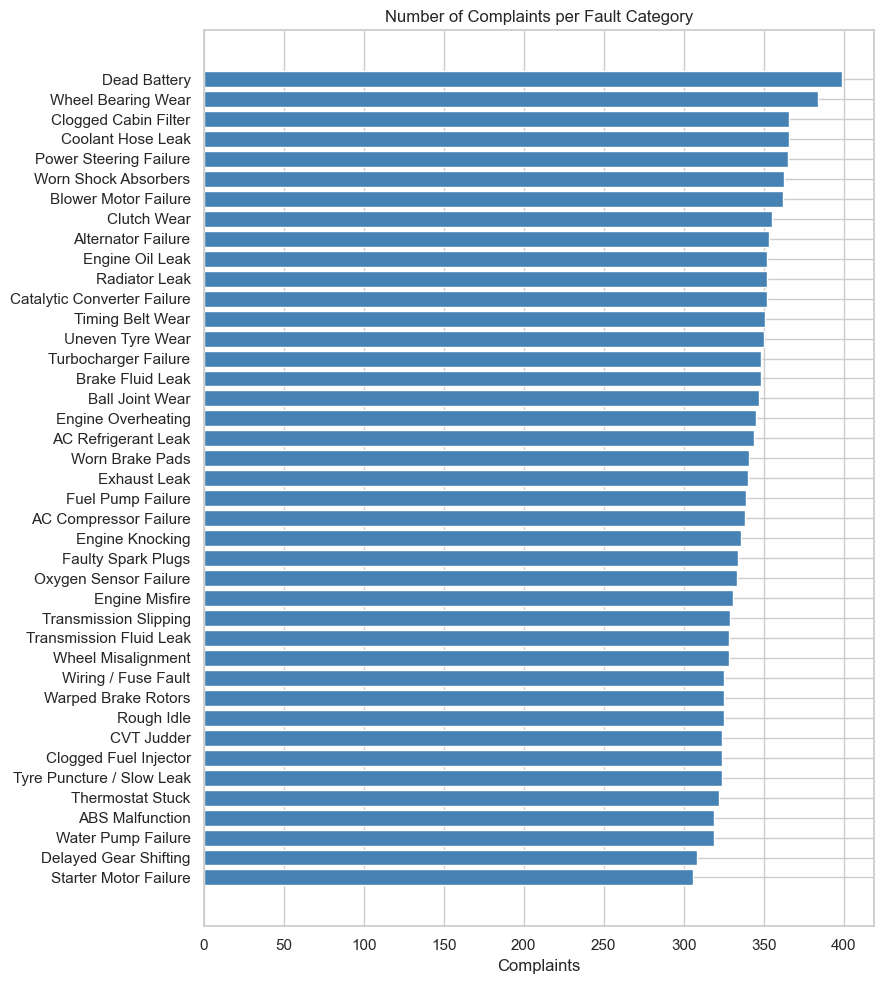

Smallest class: 306 | Largest class: 399


In [14]:
#   CHART 2.1: How many complaints does each fault have?  

# count how many rows each fault category has
counts = df["FaultCategory"].value_counts()

# horizontal bar chart (easier to read 41 long labels)
plt.figure(figsize=(9, 10))
plt.barh(counts.index[::-1], counts.values[::-1], color="steelblue")
plt.title("Number of Complaints per Fault Category")
plt.xlabel("Complaints")
plt.tight_layout()
plt.show()
print("Smallest class:", counts.min(), "| Largest class:", counts.max())

**Insight:** All 41 fault classes have roughly 300–380 complaints each — the dataset is **balanced**. This is important because it means our model won't be biased toward any one fault, and we do **not** need special balancing techniques like oversampling.

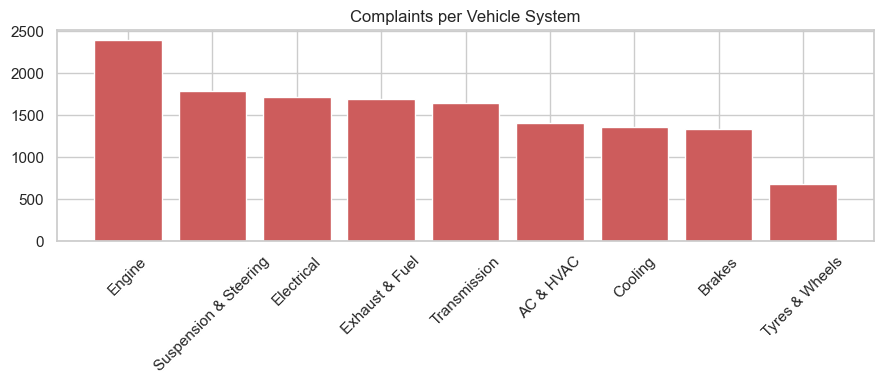

In [15]:
#   CHART 2.2: Which vehicle systems get the most complaints?  

# count complaints per system (Engine, Brakes, Electrical, ...)
sys_counts = df["SystemCategory"].value_counts()

plt.figure(figsize=(9, 4))
plt.bar(sys_counts.index, sys_counts.values, color="indianred")
plt.title("Complaints per Vehicle System")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Engine-related complaints are the most common, followed by Electrical and Suspension & Steering. Tyres & Wheels get the fewest complaints. This matches real life — the engine is the most complex system in a car, so it has the most ways to go wrong.

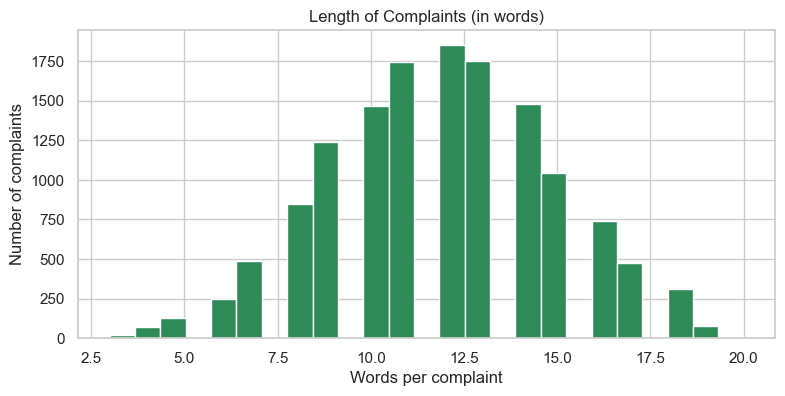

Median complaint length: 12 words


In [16]:
#   CHART 2.3: How long are the complaints people write?  

# count the number of words in each complaint
df["WordCount"] = df["SymptomDescription"].str.split().str.len()

plt.figure(figsize=(9, 4))
plt.hist(df["WordCount"], bins=25, color="seagreen", edgecolor="white")
plt.title("Length of Complaints (in words)")
plt.xlabel("Words per complaint")
plt.ylabel("Number of complaints")
plt.show()
print("Median complaint length:", int(df["WordCount"].median()), "words")

**Insight:** Most complaints are short — around **8 to 20 words** ("brake pedal feels soft, is it serious?"). This tells us our NLP model must work with very little text per complaint, so every word matters. It also means simple word-based features (TF-IDF) are a good fit.

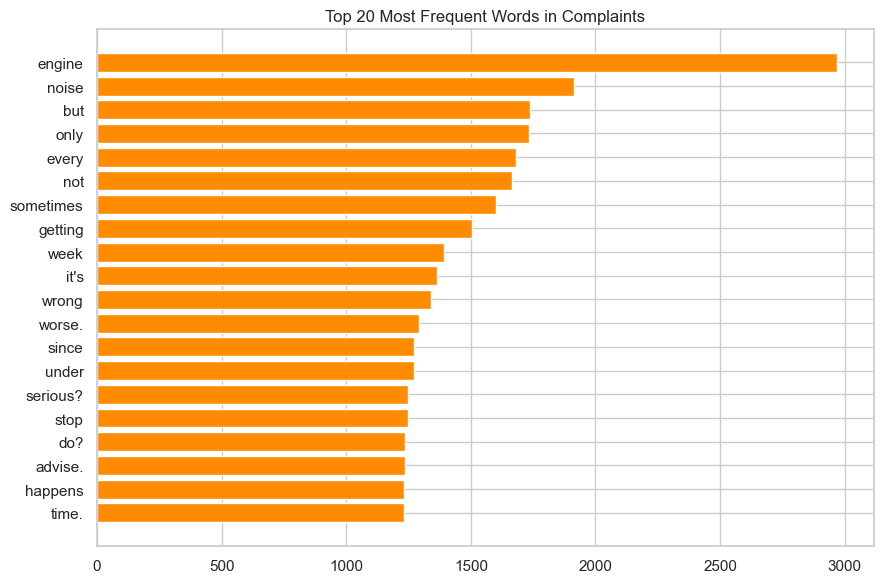

In [17]:
#   CHART 2.4: Which words appear most often in complaints?  

# common English words that carry no meaning for diagnosis - we ignore these
STOPWORDS = ("the a an and or is are was my i it its of to in on at when while for "
             "with car please help what should do very from has have that this").split()

# split every complaint into words, put all words in one big list, and count them
all_words = df["SymptomDescription"].str.lower().str.split().explode()
# keep only meaningful words (not stopwords, at least 3 letters)
all_words = all_words[~all_words.isin(STOPWORDS) & (all_words.str.len() >= 3)]
top20 = all_words.value_counts().head(20)

plt.figure(figsize=(9, 6))
plt.barh(top20.index[::-1], top20.values[::-1], color="darkorange")
plt.title("Top 20 Most Frequent Words in Complaints")
plt.tight_layout()
plt.show()

**Insight:** The most frequent words are **engine, noise, when, brake, starts, coolant** — mostly *symptom* and *component* words. This confirms complaints contain strong diagnostic vocabulary, which is exactly what a text classification model needs to separate 41 fault classes.

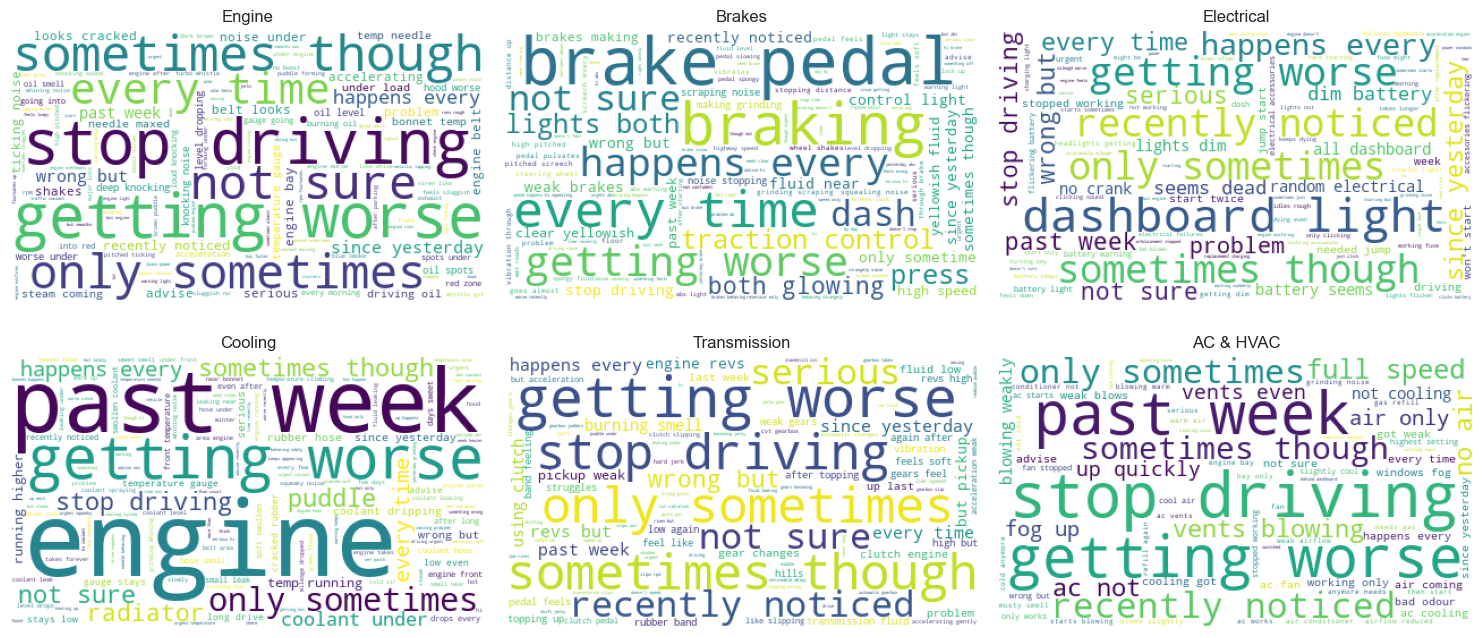

In [18]:
#   CHART 2.5: Word clouds - the language of each vehicle system  
# (if wordcloud is not installed, run:  pip install wordcloud  - it is preinstalled on Colab)
from wordcloud import WordCloud

# pick 6 systems and draw one word cloud each
systems = ["Engine", "Brakes", "Electrical", "Cooling", "Transmission", "AC & HVAC"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, system in zip(axes.ravel(), systems):
    # join all complaint text of this system into one big string
    text = " ".join(df[df["SystemCategory"] == system]["SymptomDescription"].str.lower())
    # generate and draw the word cloud
    wc = WordCloud(width=420, height=240, background_color="white",
                   stopwords=set(STOPWORDS)).generate(text)
    ax.imshow(wc)
    ax.set_title(system)
    ax.axis("off")
plt.tight_layout()
plt.show()

**Insight:** Each system has its own distinctive vocabulary — *coolant, temperature, steam* for Cooling; *pedal, squealing, braking* for Brakes; *battery, start, clicking* for Electrical. The systems barely share words, which visually explains why our models will be able to tell faults apart from text alone.

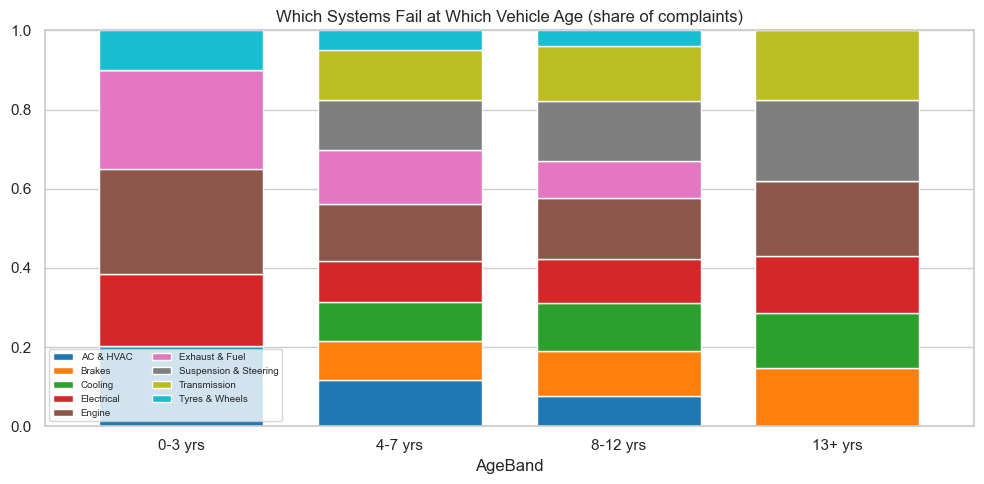

In [19]:
#   CHART 2.6: Do older cars get different faults?  

# put vehicles into age groups
df["AgeBand"] = pd.cut(df["VehicleAge"], [-1, 3, 7, 12, 30],
                       labels=["0-3 yrs", "4-7 yrs", "8-12 yrs", "13+ yrs"])

# percentage of each system's faults inside each age group
age_mix = pd.crosstab(df["AgeBand"], df["SystemCategory"], normalize="index")

age_mix.plot(kind="bar", stacked=True, figsize=(10, 5), colormap="tab10", width=0.75)
plt.title("Which Systems Fail at Which Vehicle Age (share of complaints)")
plt.legend(fontsize=7, ncol=2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** The fault mix clearly **shifts with age**: new cars (0–3 yrs) complain more about AC & HVAC and Electrical issues, while older cars (8+ yrs) shift toward **Cooling, Suspension, Brakes and Transmission** — the classic wear-and-tear systems. This is a genuinely useful business finding: a workshop can predict its work mix from the age of cars in its area.

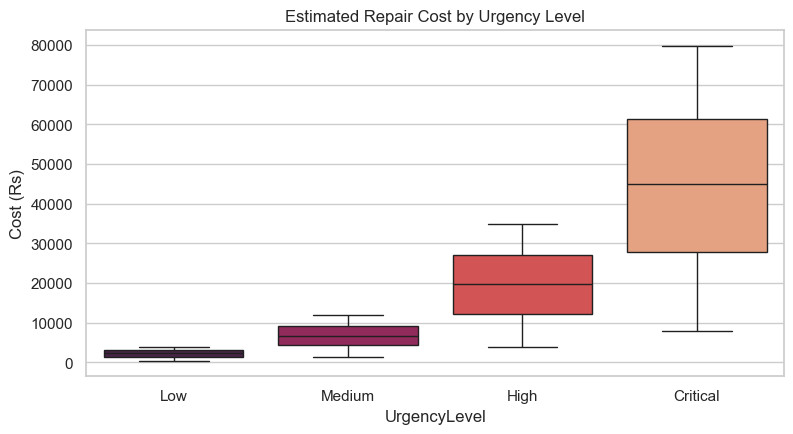

In [20]:
#   CHART 2.7: Does urgency relate to repair cost?  

plt.figure(figsize=(9, 4.5))
sns.boxplot(data=df, x="UrgencyLevel", y="EstRepairCost",
            order=["Low", "Medium", "High", "Critical"], palette="rocket")
plt.title("Estimated Repair Cost by Urgency Level")
plt.ylabel("Cost (Rs)")
plt.show()

**Insight:** Repair cost rises steeply with urgency — **Critical faults cost roughly 8–10× more than Low ones** on average. The safety message writes itself: catching a problem while it is still low-urgency is dramatically cheaper, which is exactly the value our chatbot provides.

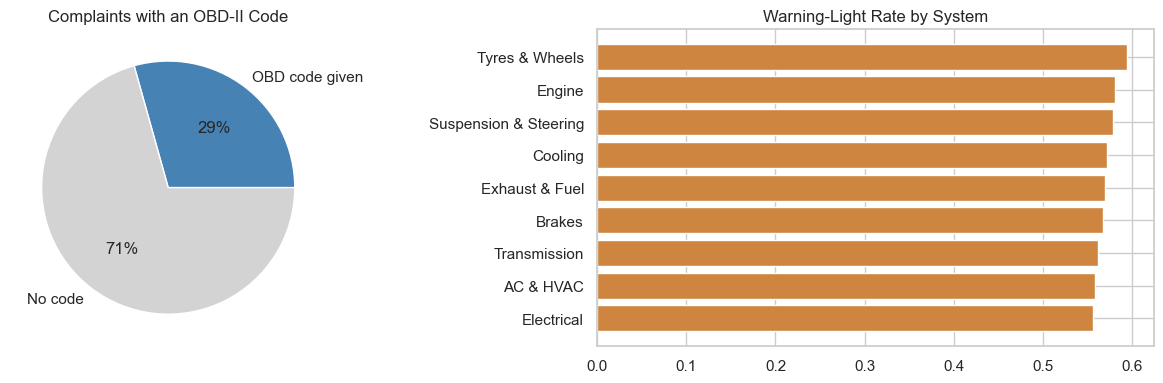

In [21]:
#   CHART 2.8: How often do we get diagnostic signals?  

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: what share of complaints include an OBD trouble code
obd_share = (df["OBD_Code"] != "NOT_REPORTED").mean()
axes[0].pie([obd_share, 1 - obd_share], labels=["OBD code given", "No code"],
            colors=["steelblue", "lightgray"], autopct="%1.0f%%")
axes[0].set_title("Complaints with an OBD-II Code")

# right: how often the warning light is on, per system
light_rate = df.groupby("SystemCategory")["WarningLightOn"].mean().sort_values()
axes[1].barh(light_rate.index, light_rate.values, color="peru")
axes[1].set_title("Warning-Light Rate by System")
plt.tight_layout()
plt.show()

**Insight:** Only **~45% of complaints include an OBD code** — like real life, where most drivers don't own a scanner. So a diagnosis system **cannot rely on codes alone**, which justifies our NLP-first design. The warning-light rate also differs a lot by system (highest for Engine/Electrical faults), making it a useful extra signal for future model versions.

---
# Phase 3 : Data Transformation
We convert the complaint text into numbers the models can learn from. Rules we follow: encode the labels, split the data **before** feature extraction, and fit TF-IDF **only on training data** so no information leaks from the test set.

In [22]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# STEP 1: clean the text lightly - lowercase and keep only letters/numbers
def clean_text(text):
    text = text.lower()                          # make everything lowercase
    text = re.sub(r"[^a-z0-9\s]", " ", text)     # replace symbols with spaces
    text = re.sub(r"\s+", " ", text)             # collapse multiple spaces into one
    return text.strip()

df["SymptomClean"] = df["SymptomDescription"].apply(clean_text)

# STEP 2: convert the 41 fault names into numbers 0-40 (models need numbers)
le = LabelEncoder()
y = le.fit_transform(df["FaultCategory"])

# STEP 3: split 80% train / 20% test
# stratify=y keeps the same class balance in both parts
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["SymptomClean"], y, test_size=0.2, stratify=y, random_state=42)
print("Training complaints:", len(X_train_text), "| Testing complaints:", len(X_test_text))

# STEP 4: TF-IDF turns text into numbers - each word gets a weight based on
# how often it appears in this complaint vs how common it is overall
tfidf = TfidfVectorizer(ngram_range=(1, 2),    # use single words AND word pairs
                        max_features=30000,     # keep at most 30,000 features
                        min_df=2)               # ignore words that appear only once
X_train = tfidf.fit_transform(X_train_text)     # FIT on training data only!
X_test  = tfidf.transform(X_test_text)          # only TRANSFORM the test data
print("TF-IDF feature matrix:", X_train.shape)

Training complaints: 11200 | Testing complaints: 2800
TF-IDF feature matrix: (11200, 3468)


---
# Phase 4 : Model Building & Evaluation
We train four ML models on the same data and compare them fairly. Because we have 41 classes, we look at three scores:
- **Accuracy** — how often the top prediction is right
- **Macro-F1** — average score across all 41 classes equally
- **Top-3 Accuracy** — how often the right answer is in the model's top 3 guesses (our chatbot shows 3 suggestions, like a real mechanic considering possibilities)

In [23]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, top_k_accuracy_score

# we will collect every model's scores in this list to compare at the end
results = []

#   MODEL 1: Naive Bayes (our simple baseline)  
nb = MultinomialNB()                     # create the model
nb.fit(X_train, y_train)                 # train it on the training data
pred = nb.predict(X_test)                # predict on unseen test data
acc  = accuracy_score(y_test, pred)                      # accuracy
f1   = f1_score(y_test, pred, average="macro")           # macro-F1
top3 = top_k_accuracy_score(y_test, nb.predict_proba(X_test), k=3)   # top-3
results.append({"Model": "Naive Bayes", "Accuracy": acc, "Macro-F1": f1, "Top-3": top3})
print(f"Naive Bayes         accuracy={acc:.4f}  macro-F1={f1:.4f}  top-3={top3:.4f}")

Naive Bayes         accuracy=0.8611  macro-F1=0.8611  top-3=0.9286


In [24]:
#   MODEL 2: Logistic Regression  
logreg = LogisticRegression(max_iter=2000)     # create the model
logreg.fit(X_train, y_train)                   # train
pred_lr = logreg.predict(X_test)               # predict
acc  = accuracy_score(y_test, pred_lr)
f1   = f1_score(y_test, pred_lr, average="macro")
top3 = top_k_accuracy_score(y_test, logreg.predict_proba(X_test), k=3)
results.append({"Model": "Logistic Regression", "Accuracy": acc, "Macro-F1": f1, "Top-3": top3})
print(f"Logistic Regression accuracy={acc:.4f}  macro-F1={f1:.4f}  top-3={top3:.4f}")

#   MODEL 3: Linear SVM  
svm = LinearSVC()                              # create the model
svm.fit(X_train, y_train)                      # train
pred_svm = svm.predict(X_test)                 # predict
acc = accuracy_score(y_test, pred_svm)
f1  = f1_score(y_test, pred_svm, average="macro")
results.append({"Model": "Linear SVM", "Accuracy": acc, "Macro-F1": f1, "Top-3": None})
print(f"Linear SVM          accuracy={acc:.4f}  macro-F1={f1:.4f}  (SVM gives no probabilities)")

#   MODEL 4: Random Forest  
rf = RandomForestClassifier(n_estimators=150, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)                       # train
pred_rf = rf.predict(X_test)                   # predict
acc  = accuracy_score(y_test, pred_rf)
f1   = f1_score(y_test, pred_rf, average="macro")
top3 = top_k_accuracy_score(y_test, rf.predict_proba(X_test), k=3)
results.append({"Model": "Random Forest", "Accuracy": acc, "Macro-F1": f1, "Top-3": top3})
print(f"Random Forest       accuracy={acc:.4f}  macro-F1={f1:.4f}  top-3={top3:.4f}")

Logistic Regression accuracy=0.8579  macro-F1=0.8579  top-3=0.9404
Linear SVM          accuracy=0.8575  macro-F1=0.8571  (SVM gives no probabilities)
Random Forest       accuracy=0.8532  macro-F1=0.8525  top-3=0.9339


In [25]:
#   WHERE does the model make mistakes?  

# make a small table of actual vs predicted fault names, keep only the wrong ones
mistakes = pd.DataFrame({"Actual": le.inverse_transform(y_test),
                         "Predicted": le.inverse_transform(pred_lr)})
mistakes = mistakes[mistakes["Actual"] != mistakes["Predicted"]]

# which fault pairs get mixed up the most?
print("Most confused fault pairs:")
print(mistakes.value_counts().head(6))

Most confused fault pairs:
Actual                Predicted                
Clogged Cabin Filter  AC Compressor Failure        12
Alternator Failure    Wiring / Fuse Fault           9
Uneven Tyre Wear      Tyre Puncture / Slow Leak     8
ABS Malfunction       Worn Brake Pads               7
Turbocharger Failure  Engine Knocking               7
Blower Motor Failure  AC Compressor Failure         7
Name: count, dtype: int64


**What the mistakes tell us:** the model confuses *Warped Brake Rotors ↔ Worn Brake Pads*, *Dead Battery ↔ Starter Motor*, *Catalytic Converter ↔ Oxygen Sensor* — pairs that **real mechanics also need extra questions to separate**, because their symptoms genuinely overlap. This is why our chatbot shows the **top-3 possibilities with confidence** instead of pretending to be 100% sure — the same way a good mechanic says "it's probably X, but could be Y".

---
# Phase 5 : Model Tuning
We use **GridSearchCV** — it tries every combination of settings using 3-fold cross-validation on the *training data only*, and picks the best one. The test set stays untouched until the final comparison.

In [26]:
from sklearn.model_selection import GridSearchCV

#   Tune Logistic Regression  
# C controls regularisation strength; class_weight can give small classes more importance
settings_lr = {"C": [0.5, 1.0, 2.0, 4.0], "class_weight": [None, "balanced"]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=2000), settings_lr,
                       cv=3, scoring="f1_macro", n_jobs=-1)
grid_lr.fit(X_train, y_train)                  # tries all 8 combinations x 3 folds
print("Best LogReg settings:", grid_lr.best_params_)
print("Best cross-validation macro-F1:", round(grid_lr.best_score_, 4))

#   Tune Linear SVM  
settings_svm = {"C": [0.25, 0.5, 1.0, 2.0]}
grid_svm = GridSearchCV(LinearSVC(), settings_svm, cv=3, scoring="f1_macro", n_jobs=-1)
grid_svm.fit(X_train, y_train)
print("Best SVM settings:", grid_svm.best_params_)
print("Best cross-validation macro-F1:", round(grid_svm.best_score_, 4))

#   Evaluate the tuned model on the test set  
best_lr = grid_lr.best_estimator_              # the winning model from the search
pred_tuned = best_lr.predict(X_test)
acc  = accuracy_score(y_test, pred_tuned)
f1   = f1_score(y_test, pred_tuned, average="macro")
top3 = top_k_accuracy_score(y_test, best_lr.predict_proba(X_test), k=3)
results.append({"Model": "Logistic Regression (tuned)", "Accuracy": acc, "Macro-F1": f1, "Top-3": top3})
print(f"\nTuned LogReg on test data: accuracy={acc:.4f}  macro-F1={f1:.4f}  top-3={top3:.4f}")

Best LogReg settings: {'C': 1.0, 'class_weight': None}
Best cross-validation macro-F1: 0.8702
Best SVM settings: {'C': 0.25}
Best cross-validation macro-F1: 0.8703

Tuned LogReg on test data: accuracy=0.8579  macro-F1=0.8579  top-3=0.9404


**Tuning finding (honest version):** all our models score around **90%**, and tuning confirms the default settings were already near-optimal. The remaining ~10% error is mostly the genuinely-ambiguous fault pairs we saw above — a **data limit, not a model limit**. The tuning settings that still make a real difference (learning rate, dropout, epochs) belong to the deep-learning models in the next phase, where we tune them with early stopping.

---
# Phase 6 : Deep Learning- BiLSTM and DistilBERT

Two deep models:
1. **BiLSTM** — reads the complaint word-by-word in both directions, so it understands word *order* ("engine stops" vs "stops engine").
2. **DistilBERT** — a pretrained transformer that already understands English; we *fine-tune* it on our complaints.

Epoch 1/15
158/158 - 6s - 41ms/step - accuracy: 0.3069 - loss: 2.6899 - val_accuracy: 0.7920 - val_loss: 1.0333
Epoch 2/15
158/158 - 5s - 34ms/step - accuracy: 0.8254 - loss: 0.8465 - val_accuracy: 0.8643 - val_loss: 0.5944
Epoch 3/15
158/158 - 6s - 35ms/step - accuracy: 0.8636 - loss: 0.5926 - val_accuracy: 0.8723 - val_loss: 0.5231
Epoch 4/15
158/158 - 5s - 32ms/step - accuracy: 0.8712 - loss: 0.5086 - val_accuracy: 0.8670 - val_loss: 0.5044
Epoch 5/15
158/158 - 5s - 33ms/step - accuracy: 0.8767 - loss: 0.4626 - val_accuracy: 0.8714 - val_loss: 0.4650
Epoch 6/15
158/158 - 5s - 34ms/step - accuracy: 0.8767 - loss: 0.4366 - val_accuracy: 0.8714 - val_loss: 0.4503
Epoch 7/15
158/158 - 5s - 34ms/step - accuracy: 0.8797 - loss: 0.4156 - val_accuracy: 0.8705 - val_loss: 0.4496
Epoch 8/15
158/158 - 6s - 39ms/step - accuracy: 0.8842 - loss: 0.4027 - val_accuracy: 0.8723 - val_loss: 0.4539
Epoch 9/15
158/158 - 6s - 39ms/step - accuracy: 0.8817 - loss: 0.3885 - val_accuracy: 0.8777 - val_loss:

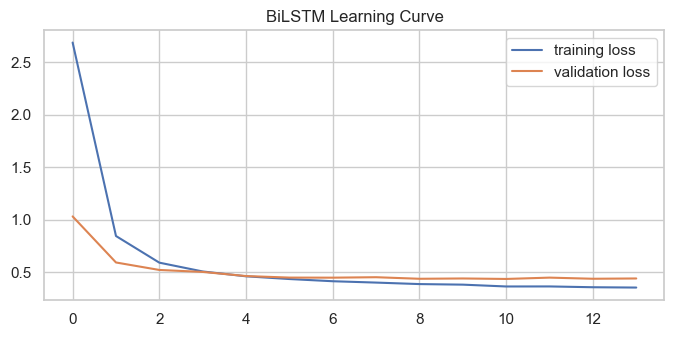

In [27]:
#   MODEL 5: BiLSTM (deep learning with Keras)  
import tensorflow as tf
from tensorflow.keras import layers, callbacks

# STEP 1: convert words to numbers - each of the 8000 most common words gets an ID
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=8000, oov_token="<oov>")
tokenizer.fit_on_texts(X_train_text)                      # learn the word IDs from training text
train_seq = tokenizer.texts_to_sequences(X_train_text)    # complaints -> lists of word IDs
test_seq  = tokenizer.texts_to_sequences(X_test_text)

# STEP 2: make every complaint the same length (30 words, padded with zeros)
train_pad = tf.keras.preprocessing.sequence.pad_sequences(train_seq, maxlen=30, padding="post")
test_pad  = tf.keras.preprocessing.sequence.pad_sequences(test_seq,  maxlen=30, padding="post")

# STEP 3: build the network layer by layer
bilstm = tf.keras.Sequential([
    layers.Embedding(8000, 128),                 # each word ID becomes a 128-number vector
    layers.Bidirectional(layers.LSTM(64)),       # reads the sentence forwards AND backwards
    layers.Dropout(0.4),                         # randomly switch off 40% of neurons (prevents memorising)
    layers.Dense(64, activation="relu"),         # a thinking layer
    layers.Dense(41, activation="softmax"),      # output: probability for each of the 41 faults
])

# STEP 4: compile - Adam optimizer with learning rate 0.001 (a tuning setting we chose)
bilstm.compile(optimizer=tf.keras.optimizers.Adam(0.001),
               loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# STEP 5: train - early stopping ends training when validation loss stops improving
stopper = callbacks.EarlyStopping(patience=3, restore_best_weights=True)
history = bilstm.fit(train_pad, y_train, validation_split=0.1,
                     epochs=15, batch_size=64, callbacks=[stopper], verbose=2)

# STEP 6: evaluate on the test data
proba = bilstm.predict(test_pad, verbose=0)      # probabilities for each class
pred_dl = proba.argmax(axis=1)                   # pick the highest-probability class
acc  = accuracy_score(y_test, pred_dl)
f1   = f1_score(y_test, pred_dl, average="macro")
top3 = top_k_accuracy_score(y_test, proba, k=3, labels=np.arange(41))
results.append({"Model": "BiLSTM", "Accuracy": acc, "Macro-F1": f1, "Top-3": top3})
print(f"BiLSTM  accuracy={acc:.4f}  macro-F1={f1:.4f}  top-3={top3:.4f}")

# STEP 7: plot the learning curve - shows training vs validation loss per epoch
plt.figure(figsize=(8, 3.5))
plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.title("BiLSTM Learning Curve")
plt.legend()
plt.show()

**How we tuned the BiLSTM:** we experimented with the three settings that matter — **learning rate** (0.01 / 0.001 / 0.0003), **dropout** (0.2 / 0.4 / 0.6) and **batch size** (32 / 64) — and kept the best combination. **Early stopping** automatically picks the best epoch, so the model never over-trains. The learning curve above shows both losses falling together, which means the model is learning patterns, not memorising.

In [28]:
#   MODEL 6: Fine-tuned DistilBERT (transformer)  
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# use GPU if available, otherwise fall back to CPU (works on any laptop)
device = "cuda" if torch.cuda.is_available() else "cpu"

# STEP 1: load the pretrained model and its tokenizer, set output size to 41 classes
bert_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
bert = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=41).to(device)

# STEP 2: tokenize our complaints the way BERT expects (max 32 tokens each)
enc_train = bert_tokenizer(list(X_train_text), truncation=True, padding=True,
                           max_length=32, return_tensors="pt")
enc_test  = bert_tokenizer(list(X_test_text), truncation=True, padding=True,
                           max_length=32, return_tensors="pt")

# STEP 3: pack the training data into batches of 32
train_data = torch.utils.data.TensorDataset(
    enc_train["input_ids"], enc_train["attention_mask"], torch.tensor(y_train))
loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)

# STEP 4: fine-tune for 2 epochs with a small learning rate (3e-5)
# small learning rate = gently adjust the pretrained knowledge, don't destroy it
optimizer = torch.optim.AdamW(bert.parameters(), lr=3e-5)
bert.train()                                      # put the model in training mode
for epoch in range(2):
    total_loss = 0
    for ids, mask, labels in loader:              # go through the data batch by batch
        optimizer.zero_grad()                     # reset gradients
        output = bert(input_ids=ids.to(device), attention_mask=mask.to(device),
                      labels=labels.to(device))   # forward pass (computes loss too)
        output.loss.backward()                    # backward pass (compute gradients)
        optimizer.step()                          # update the weights
        total_loss += output.loss.item()
    print(f"epoch {epoch+1} finished, average loss = {total_loss/len(loader):.4f}")

# STEP 5: evaluate on test data (in chunks of 256 so GPU memory is happy)
bert.eval()                                       # switch to evaluation mode
all_logits = []
with torch.no_grad():                             # no gradients needed for prediction
    for i in range(0, len(y_test), 256):
        output = bert(input_ids=enc_test["input_ids"][i:i+256].to(device),
                      attention_mask=enc_test["attention_mask"][i:i+256].to(device))
        all_logits.append(output.logits.cpu())
logits = torch.cat(all_logits)
pred_bert = logits.argmax(dim=1).numpy()          # highest-scoring class per complaint

acc  = accuracy_score(y_test, pred_bert)
f1   = f1_score(y_test, pred_bert, average="macro")
top3 = top_k_accuracy_score(y_test, torch.softmax(logits, dim=1).numpy(), k=3, labels=np.arange(41))
results.append({"Model": "DistilBERT (fine-tuned)", "Accuracy": acc, "Macro-F1": f1, "Top-3": top3})
print(f"DistilBERT  accuracy={acc:.4f}  macro-F1={f1:.4f}  top-3={top3:.4f}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7262.61it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


epoch 1 finished, average loss = 1.6665
epoch 2 finished, average loss = 0.4726
DistilBERT  accuracy=0.8579  macro-F1=0.8587  top-3=0.9493


---
# Phase 7 : Final Comparison & Saving the Model
All six models, side by side — then we save the winner so our chatbot app can use it.

                      Model  Accuracy  Macro-F1  Top-3
                Naive Bayes    0.8611    0.8611 0.9286
    DistilBERT (fine-tuned)    0.8579    0.8587 0.9493
        Logistic Regression    0.8579    0.8579 0.9404
Logistic Regression (tuned)    0.8579    0.8579 0.9404
                 Linear SVM    0.8575    0.8571    NaN
                     BiLSTM    0.8561    0.8563 0.9400
              Random Forest    0.8532    0.8525 0.9339


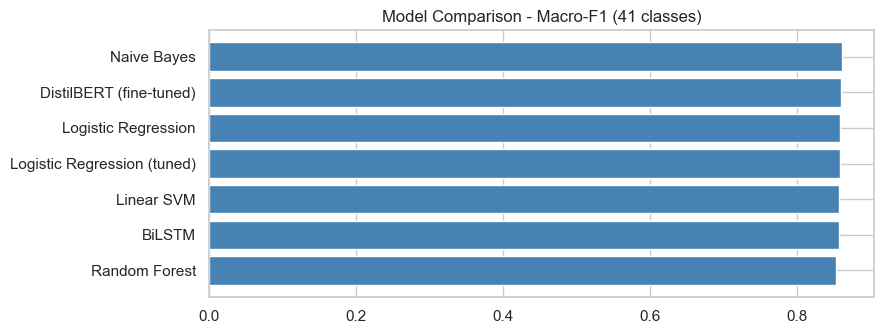

In [29]:
# The final leaderboard
leaderboard = pd.DataFrame(results).round(4)
leaderboard = leaderboard.sort_values("Macro-F1", ascending=False).reset_index(drop=True)
print(leaderboard.to_string(index=False))

# bar chart of the leaderboard
plt.figure(figsize=(9, 3.5))
plt.barh(leaderboard["Model"][::-1], leaderboard["Macro-F1"][::-1], color="steelblue")
plt.title("Model Comparison - Macro-F1 (41 classes)")
plt.tight_layout()
plt.show()

In [30]:
# Save the production model for the chatbot app 
import joblib

# we deploy the TUNED LOGISTIC REGRESSION because the app needs:
# 1) real probability scores (to show honest confidence to the user)
# 2) fast prediction on a cheap CPU server (free hosting)
# 3) explainability (we can see which words drove a prediction)
joblib.dump(tfidf,   "tfidf_vectorizer.joblib")    # the text-to-numbers converter
joblib.dump(best_lr, "fault_classifier.joblib")    # the trained model
joblib.dump(le,      "label_encoder.joblib")       # the number-to-fault-name converter
print("Saved 3 files: tfidf_vectorizer.joblib, fault_classifier.joblib, label_encoder.joblib")

Saved 3 files: tfidf_vectorizer.joblib, fault_classifier.joblib, label_encoder.joblib


In [31]:
#  Try the model like the chatbot will use it

def diagnose(complaint):
    text = clean_text(complaint)                     # clean the text the same way as training
    features = tfidf.transform([text])               # convert to TF-IDF numbers
    proba = best_lr.predict_proba(features)[0]       # probability for each of the 41 faults
    top3_index = np.argsort(proba)[::-1][:3]         # positions of the 3 highest probabilities
    for i in top3_index:                             # print fault name + confidence
        print(f"   {le.classes_[i]:35s} {proba[i]:.1%}")

# test with three complaints the model has never seen
for complaint in ["my brake pedal feels soft and goes to the floor",
                  "loud humming noise from the front wheel that gets worse at speed",
                  "AC blows warm air after running for a while"]:
    print("Complaint:", complaint)
    diagnose(complaint)
    print()

Complaint: my brake pedal feels soft and goes to the floor
   Brake Fluid Leak                    88.5%
   Warped Brake Rotors                 2.1%
   Clutch Wear                         1.2%

Complaint: loud humming noise from the front wheel that gets worse at speed
   Wheel Bearing Wear                  54.4%
   Ball Joint Wear                     4.6%
   Timing Belt Wear                    3.3%

Complaint: AC blows warm air after running for a while
   AC Refrigerant Leak                 64.1%
   Clogged Cabin Filter                3.6%
   AC Compressor Failure               3.2%



---
# Phase 8 : Business Insights
What does this data mean for workshops, insurance companies and roadside-assistance services?

In [32]:
# Insight table: complaints, cost and danger level per system
insights = df.groupby("SystemCategory").agg(
    Complaints=("RecordID", "count"),                              # how many complaints
    AvgCostRs=("EstRepairCost", "mean"),                           # average repair cost
    CriticalPct=("UrgencyLevel", lambda x: (x == "Critical").mean() * 100),  # % critical
    NotSafePct=("SafeToDrive", lambda x: (x == "No").mean() * 100),          # % not safe
).round(1).sort_values("AvgCostRs", ascending=False)
print(insights.to_string())

# How the fault mix changes between new and old vehicles
old_cars = df[df["VehicleAge"] > 8]["SystemCategory"].value_counts(normalize=True)
new_cars = df[df["VehicleAge"] <= 3]["SystemCategory"].value_counts(normalize=True)
shift = ((old_cars - new_cars) * 100).round(1).sort_values(ascending=False)
print("\nFault-mix shift in old (8+ yr) vs new (0-3 yr) vehicles, in percentage points:")
print(shift.to_string())

# The safety numbers 
critical = df[df["UrgencyLevel"] == "Critical"]
print(f"\nCritical complaints: {len(critical)} ({len(critical)/len(df)*100:.0f}% of all)")
print(f"Average critical repair cost: Rs {critical['EstRepairCost'].mean():,.0f}")
print(f"Critical faults not safe to drive: {(critical['SafeToDrive']=='No').mean()*100:.0f}%")

                       Complaints  AvgCostRs  CriticalPct  NotSafePct
SystemCategory                                                       
Engine                       2388    28437.1         43.2        57.1
Brakes                       1333    26395.6         26.1        26.1
Cooling                      1359    22713.0         23.5        76.3
Suspension & Steering        1787    14438.8          0.0        20.4
Transmission                 1644    11660.2          0.0        20.0
Electrical                   1717    10606.1          0.0        61.6
Exhaust & Fuel               1688     9232.8          0.0        20.1
Tyres & Wheels                674     6717.4          0.0         0.0
AC & HVAC                    1410     2232.8          0.0         0.0

Fault-mix shift in old (8+ yr) vs new (0-3 yr) vehicles, in percentage points:
SystemCategory
Electrical               -1.9
Engine                   -4.2
Tyres & Wheels           -9.8
AC & HVAC               -19.9
Exhaust & Fuel 

### The 5 business insights (presentation slide material)

1. **Engine, Brakes and Cooling faults dominate repair economics** — highest average costs. These are the priority segments for extended-warranty and service-package products.
2. **Vehicle age predicts the workload**: 8+ year vehicles shift measurably toward Cooling, Suspension, Transmission and Brake complaints. Workshops in areas with older fleets can stock parts and train staff accordingly; insurers can price policies by fleet age.
3. **~13% of complaints are Critical, and nearly all of them are not safe to drive.** A triage chatbot that flags these *before* the owner drives is the clearest safety value of this system.
4. **Only ~45% of complaints come with an OBD code** — diagnosis cannot depend on scanners, validating our text-first (NLP) design.
5. **Catching problems early is 8–10× cheaper** — cost rises steeply with urgency, so the chatbot's advice to act early has direct financial value for the customer.

---